# Sizing & Drawing of Inverter-Based Barthelemy OTA

**Copyright 2026 Simon Dorrer**

SPDX-License-Identifier: Apache-2.0 WITH SHL-2.1
You may obtain a copy of the License at
http://www.apache.org/licenses/LICENSE-2.0

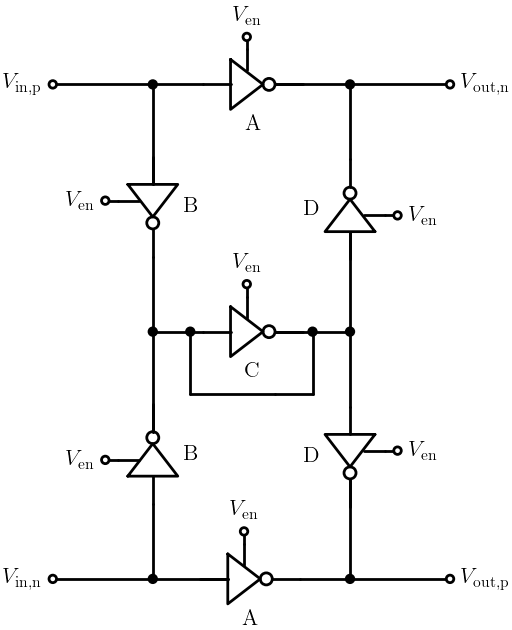

In [1]:
# Draw Circuit
import matplotlib
matplotlib.rcParams.update({
    "text.usetex": True,
    "font.family": "lmodern"
})
import schemdraw as sd
import schemdraw.elements as elm
import schemdraw.logic as logic
sd.svgconfig.svg2 = False

# Layout spacing parameters (adjust these to change the overall layout)
SP = 1.5       # standard junction spacing
EN = 0.25      # enable pin stub length
IN_LEN = 1.0   # input lead length
OUT_LEN = 2.0  # output terminal lead length
CM_GAP = 0.5   # extra gap at common-mode node
C_OFS = 0.75   # C inverter horizontal offset from CM node
C_DROP = 1.25  # C inverter feedback loop vertical drop

with sd.Drawing() as d:
    d.config(unit=2, fontsize=16)

    # --- Vinp → Inverter A1 → Voutn (top row) ---
    elm.Dot(open=True).label(r'$V_\mathrm{in,p}$', loc='left', ofst=0.15)
    elm.Line().right().length(2 * IN_LEN).dot()
    elm.Line().right().length(IN_LEN)
    A1 = logic.Tristate().right().label(r'$\mathrm{A}$', loc='bottom')
    elm.Line().at(A1.c).up().length(EN).dot(open=True).label(r'$V_\mathrm{en}$', loc='right', ofst=0.15)
    n_TR = elm.Line().at(A1.out).right().length(SP).dot()
    elm.Line().at(n_TR.end).right().length(OUT_LEN).dot(open=True).label(r'$V_\mathrm{out,n}$', loc='right', ofst=0.15)

    # --- Inverter D1 (right column, down from Voutn → CM node) ---
    elm.Line().at(n_TR.end).down().length(SP)
    D1 = logic.Tristate().down().label(r'$\mathrm{D}$', loc='top').reverse()
    elm.Line().at(D1.c).right().length(EN).dot(open=True).label(r'$V_\mathrm{en}$', loc='right', ofst=0.15)
    n_CMR = elm.Line().at(D1.in1).down().length(SP + CM_GAP).dot()

    # --- Inverter D2 (right column, CM node → Voutp) ---
    elm.Line().at(n_CMR.end).down().length(SP)
    D2 = logic.Tristate().down().label(r'$\mathrm{D}$', loc='top')
    elm.Line().at(D2.c).right().length(EN).dot(open=True).label(r'$V_\mathrm{en}$', loc='right', ofst=0.15)
    n_BR = elm.Line().at(D2.out).down().length(SP + CM_GAP).dot()
    elm.Line().at(n_BR.end).right().length(OUT_LEN).dot(open=True).label(r'$V_\mathrm{out,p}$', loc='right', ofst=0.15)

    # --- Vinn ← Inverter A2 (bottom row) ---
    elm.Line().at(n_BR.end).left().length(IN_LEN)
    A2 = logic.Tristate().left().label(r'$\mathrm{A}$', loc='bottom').reverse().flip()
    elm.Line().at(A2.c).up().length(EN).dot(open=True).label(r'$V_\mathrm{en}$', loc='right', ofst=0.15)
    n_BL = elm.Line().at(A2.in1).left().length(SP).dot()
    elm.Line().at(n_BL.end).left().length(2 * IN_LEN).dot(open=True).label(r'$V_\mathrm{in,n}$', loc='left', ofst=0.15)

    # --- Inverter B2 (left column, up from Vinn → CM node) ---
    elm.Line().at(n_BL.end).up().length(SP)
    B2 = logic.Tristate().up().label(r'$\mathrm{B}$', loc='bottom')
    elm.Line().at(B2.c).left().length(EN).dot(open=True).label(r'$V_\mathrm{en}$', loc='left', ofst=0.15)
    n_CML = elm.Line().at(B2.out).up().length(SP + CM_GAP).dot()

    # --- Inverter C1 (self-bias feedback loop on internal CM node) ---
    n_Cin = elm.Line().at(n_CML.end).right().length(C_OFS).dot()
    elm.Line().at(n_Cin.end).right().length(EN)
    C1 = logic.Tristate().right().label(r'$\mathrm{C}$', loc='bottom')
    elm.Line().at(C1.c).up().length(EN).dot(open=True).label(r'$V_\mathrm{en}$', loc='right', ofst=0.15)
    elm.Line().at(C1.out).right().length(SP)
    elm.Line().at(n_Cin.end).down().length(C_DROP)
    elm.Line().right().tox(C1.out)
    elm.Line().right().length(C_OFS)
    elm.Line().up().toy(C1.out).dot()

    # --- Inverter B1 (left column, CM node → Vinp) ---
    elm.Line().at(n_CML.end).up().length(SP)
    B1 = logic.Tristate().up().label(r'$\mathrm{B}$', loc='bottom').reverse()
    elm.Line().at(B1.c).left().length(EN).dot(open=True).label(r'$V_\mathrm{en}$', loc='left', ofst=0.15)
    elm.Line().at(B1.in1).up().length(SP + CM_GAP)

    # Save the schematic
    d.save('figures/inverter_based_ota_barthelemy_circuit.svg')
    d.save('figures/inverter_based_ota_barthelemy_circuit.pdf')

# Specifications

In [2]:
# Supply voltage
VDD = 1.5

# Input common-mode voltage
Vcm_in = VDD / 2

# Output common-mode voltage
Vcm_out = VDD / 2

# Output current
i_out = 3.0e-3

# Length per inverter type (PMOS and NMOS share the same length within each inverter)
# l_MA = 0.13 # minimum length to maximize bandwidth and decrease area, but also increase mismatch and reduce gain
# l_MB = 0.13
# l_MC = 0.13
# l_MD = 0.13
l_MA = 0.5  # tradeoff between gain, bandwidth, area, and mismatch
l_MB = 0.5
l_MC = 0.5
l_MD = 0.5
# l_MA = 1.0  # higher length to reduce mismatch and increase gain, but also increase area and reduce bandwidth
# l_MB = 1.0
# l_MC = 1.0
# l_MD = 1.0

# Load capacitance
C_load = 10e-12

In [3]:
# Print Specifications
print("=" * 60)
print("Specifications:")
print("=" * 60)
print(f"Supply Voltage (VDD):          {VDD} V")
print(f"Input Common-Mode (Vcm_in):    {Vcm_in} V")
print(f"Output Common-Mode (Vcm_out):  {Vcm_out} V")
print(f"Output Current (i_out):        {i_out*1e3:.2f} mA")
print(f"Transistor Length (L_MA):      {l_MA} µm")
print(f"Transistor Length (L_MB):      {l_MB} µm")
print(f"Transistor Length (L_MC):      {l_MC} µm")
print(f"Transistor Length (L_MD):      {l_MD} µm")
print(f"Load Capacitance (C_load):     {C_load*1e12:.2f} pF")
print("=" * 60)

Specifications:
Supply Voltage (VDD):          1.5 V
Input Common-Mode (Vcm_in):    0.75 V
Output Common-Mode (Vcm_out):  0.75 V
Output Current (i_out):        3.00 mA
Transistor Length (L_MA):      0.5 µm
Transistor Length (L_MB):      0.5 µm
Transistor Length (L_MC):      0.5 µm
Transistor Length (L_MD):      0.5 µm
Load Capacitance (C_load):     10.00 pF


# Load SG13G2 Data Tables

In [4]:
from pygmid import Lookup as lk
import numpy as np
lv_nmos = lk('data/sg13g2_lv_nmos.mat')
lv_pmos = lk('data/sg13g2_lv_pmos.mat')
# list of parameters: VGS, VDS, VSB, L, W, NFING, ID, VT, GM, GMB, GDS, CGG, CGB, CGD, CGS, CDD, CSS, STH, SFL
# if not specified, minimum L, VDS=max(vgs)/2=0.9 and VSB=0 are used 

# Inverter (A) Sizing

In [5]:
# NMOS (MA) Sizing
print("=" * 60)
print("NMOS (MA) Sizing:")
print("=" * 60, "\n")

# Vgs of NMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_nMA = Vcm_in
print(f"Vgs_nMA = {Vgs_nMA} V")

# Vds of NMOS
Vds_nMA = Vcm_out
print(f"Vds_nMA = {Vds_nMA} V")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_nMA = lv_nmos.lookup("GM_ID", L=l_MA, VGS=Vgs_nMA, VDS=Vds_nMA, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_nMA), 2)} uS/uA")
gm_nMA = i_out * gm_id_nMA
print(f"gm_nMA = {round(float(gm_nMA) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_nMA = lv_nmos.lookup("GM_GDS", L=l_MA, VGS=Vgs_nMA, VDS=Vds_nMA, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_nMA), 2)}")
gds_nMA = gm_nMA / gm_gds_nMA
print(f"gds_nMA = {round(float(gds_nMA) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb
print(f"Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb:")
print("-" * 60)
gm_cgg_nMA = lv_nmos.lookup("GM_CGG", L=l_MA, VGS=Vgs_nMA, VDS=Vds_nMA, VSB=0)
Cgg_nMA = gm_nMA / gm_cgg_nMA
print(f"Cgg_nMA = {round(float(Cgg_nMA) * 1e15, 2)}fF")
print("-" * 60 + "\n")

# Transit Frequency (fT) @ current gain = 1
print(f"Transit Frequency (fT) @ current gain = 1:")
f_T_nMA = gm_cgg_nMA / (2 * np.pi)
print(f"f_T_nMA = {round(float(f_T_nMA) * 1e-9, 2)}GHz")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
id_w_nMA = lv_nmos.lookup("ID_W", L=l_MA, VGS=Vgs_nMA, VDS=Vds_nMA, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_nMA * 1e6), 2)} uA/um")
w_nMA = i_out / id_w_nMA
print(f"w_nMA = {round(float(w_nMA), 2)}um")
print("-" * 60 + "\n")

# Thermal Noise PSD at 1Hz (STH)
print(f"Thermal Noise PSD at 1Hz (STH):")
print("-" * 60)
sth_gm = lv_nmos.lookup('STH_GM', GM_ID=gm_id_nMA, L=l_MA, VDS=Vds_nMA, VSB=0)
sth = sth_gm * gm_nMA
print(f"STH(gm/ID, L, VDS, VSB) = {round(float(sth * 1e24), 2)} pV²/Hz (thermal noise psd at 1 Hz)")
print("-" * 60 + "\n")

# Flicker Corner Frequency (fco)
print(f"Flicker Corner Frequency (fco):")
print("-" * 60)
fco = lv_nmos.lookup('SFL_STH', GM_ID=gm_id_nMA, L=l_MA, VDS=Vds_nMA, VSB=0)
print(f"fco(gm/ID, L, VDS, VSB) = {round(float(fco * 1e-6), 2)} MHz (flicker corner frequency @ flicker noise PSD = thermal noise PSD)")
print("=" * 60)

NMOS (MA) Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_nMA = 0.75 V
Vds_nMA = 0.75 V
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 3.95 uS/uA
gm_nMA = 11.86mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 23.74
gds_nMA = 0.5mS
------------------------------------------------------------

Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb:
------------------------------------------------------------
Cgg_nMA = 198.45fF
------------------------------------------------------------

Transit Frequency (fT) @ current gain = 1:
f_T_nMA = 9.51GHz
------------------------------------------------------------

Width (W):
------------------------------------------------------------
ID/W(L, VGS, VDS, VSB) = 74

In [6]:
# PMOS (MA) Sizing
print("=" * 60)
print("PMOS (MA) Sizing:")
print("=" * 60, "\n")

# Vgs of PMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_pMA = VDD - Vcm_in
print(f"Vgs_pMA = {Vgs_pMA} V")

# Vds of PMOS
Vds_pMA = VDD - Vcm_out
print(f"Vds_pMA = {Vds_pMA} V")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_pMA = gm_id_nMA # lv_pmos.lookup("GM_ID", L=l_MA, VGS=Vgs_pMA, VDS=Vds_pMA, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_pMA), 2)} uS/uA")
gm_pMA = i_out * gm_id_pMA
print(f"gm_pMA = gm_pMA = {round(float(gm_pMA) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_pMA = lv_pmos.lookup("GM_GDS", L=l_MA, VGS=Vgs_pMA, VDS=Vds_pMA, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_pMA), 2)}")
gds_pMA = gm_pMA / gm_gds_pMA
print(f"gds_pMA = {round(float(gds_pMA) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb
print(f"Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb:")
print("-" * 60)
gm_cgg_pMA = lv_pmos.lookup("GM_CGG", L=l_MA, VGS=Vgs_pMA, VDS=Vds_pMA, VSB=0)
Cgg_pMA = gm_pMA / gm_cgg_pMA
print(f"Cgg_pMA = {round(float(Cgg_pMA) * 1e15, 2)}fF")
print("-" * 60 + "\n")

# Transit Frequency (fT) @ current gain = 1
print(f"Transit Frequency (fT) @ current gain = 1:")
f_T_pMA = gm_cgg_pMA / (2 * np.pi)
print(f"f_T_pMA = {round(float(f_T_pMA) * 1e-9, 2)}GHz")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
id_w_pMA = lv_pmos.lookup("ID_W", L=l_MA, VGS=Vgs_pMA, VDS=Vds_pMA, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_pMA * 1e6), 2)} uA/um")
w_pMA = i_out / id_w_pMA
print(f"w_pMA = {round(float(w_pMA), 2)}um")
print("-" * 60 + "\n")

# Thermal Noise PSD at 1Hz (STH)
print(f"Thermal Noise PSD at 1Hz (STH):")
print("-" * 60)
sth_gm = lv_pmos.lookup('STH_GM', GM_ID=gm_id_pMA, L=l_MA, VDS=Vds_pMA, VSB=0)
sth = sth_gm * gm_pMA
print(f"STH(gm/ID, L, VDS, VSB) = {round(float(sth * 1e24), 2)} pV²/Hz (thermal noise psd at 1 Hz)")
print("-" * 60 + "\n")

# Flicker Corner Frequency (fco)
print(f"Flicker Corner Frequency (fco):")
print("-" * 60)
fco = lv_pmos.lookup('SFL_STH', GM_ID=gm_id_pMA, L=l_MA, VDS=Vds_pMA, VSB=0)
print(f"fco(gm/ID, L, VDS, VSB) = {round(float(fco * 1e-6), 2)} MHz (flicker corner frequency @ flicker noise PSD = thermal noise PSD)")
print("=" * 60)

PMOS (MA) Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_pMA = 0.75 V
Vds_pMA = 0.75 V
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 3.95 uS/uA
gm_pMA = gm_pMA = 11.86mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 62.09
gds_pMA = 0.19mS
------------------------------------------------------------

Gate capacitance (Cgg), Cgg = Cgs + Cgb + Cdb:
------------------------------------------------------------
Cgg_pMA = 957.21fF
------------------------------------------------------------

Transit Frequency (fT) @ current gain = 1:
f_T_pMA = 1.97GHz
------------------------------------------------------------

Width (W):
------------------------------------------------------------
ID/W(L, VGS, VDS,

In [7]:
# PMOS / NMOS Width Ratio
w_ratio_MA = w_pMA / w_nMA
print(f"PMOS/NMOS Width Ratio (W_pMA/W_nMA) = {round(float(w_ratio_MA), 2)}")

PMOS/NMOS Width Ratio (W_pMA/W_nMA) = 6.22


# Define Widths and Fingers

In [8]:
def calculate_finger_options(width1_um, width2_um, target_ratio, min_finger_width=1.0, max_finger_width=20.0, max_options=10, finger_width_step=1.0):
    """
    Calculate practicable finger configurations for two transistors maintaining their width ratio.
    Finger widths are constrained to multiples of finger_width_step (default: 0.5um).
    Only returns configurations with an even number of fingers.
    Both transistors must have the SAME number of fingers.
    
    Parameters:
    -----------
    width1_um : float
        Width of first transistor in micrometers (e.g., PMOS)
    width2_um : float
        Width of second transistor in micrometers (e.g., NMOS)
    target_ratio : float
        Target width ratio (width1 / width2)
    min_finger_width : float
        Minimum practical finger width in micrometers (default: 1.0um)
    max_finger_width : float
        Maximum practical finger width in micrometers (default: 20.0um)
    max_options : int
        Maximum number of options to return (default: 10)
    finger_width_step : float
        Step size for finger width in micrometers (default: 1.0um)
    
    Returns:
    --------
    list of tuples : (nf, fw1, fw2, actual_ratio, error_percent)
        nf: number of fingers (same for both transistors)
        fw1: finger width for transistor 1
        fw2: finger width for transistor 2
        List of viable configurations sorted by error and preference
    """
    
    combinations = []
    
    # Try different even numbers of fingers
    # Start from 2 and go up to a reasonable maximum
    max_nf = int(max(width1_um, width2_um) / min_finger_width) + 2
    
    for nf in range(2, max_nf + 1, 2):  # Only even numbers
        # Calculate required finger widths for this number of fingers
        fw1_exact = width1_um / nf
        fw2_exact = width2_um / nf
        
        # Round to nearest finger_width_step
        fw1 = round(fw1_exact / finger_width_step) * finger_width_step
        fw2 = round(fw2_exact / finger_width_step) * finger_width_step
        
        # Check if both finger widths are within acceptable range
        if (min_finger_width <= fw1 <= max_finger_width and 
            min_finger_width <= fw2 <= max_finger_width):
            
            # Calculate actual widths with rounded finger widths
            actual_width1 = nf * fw1
            actual_width2 = nf * fw2
            
            # Calculate actual ratio
            actual_ratio = actual_width1 / actual_width2
            
            # Calculate percentage error from target ratio
            error_percent = abs(actual_ratio - target_ratio) / target_ratio * 100
            
            # Add to combinations
            combinations.append((nf, fw1, fw2, actual_ratio, error_percent))
    
    # Sort by preference: minimize error (but less aggressive), then prefer good finger widths
    def preference_score(combo):
        nf, fw1, fw2, actual_ratio, error_percent = combo
        # Primary: minimize ratio error (less aggressive weight to allow more error)
        error_score = error_percent * 2  # Reduced from 10 to 2
        # Secondary: prefer finger widths around 3-8um range
        width_score1 = abs(fw1 - 5.0)
        width_score2 = abs(fw2 - 5.0)
        # Tertiary: prefer fewer fingers
        finger_score = nf * 0.01
        return error_score + width_score1 + width_score2 + finger_score
    
    combinations.sort(key=preference_score)
    
    return combinations[:max_options]

In [9]:
# Calculate finger configurations for all transistors
print("=" * 60)
print('Finger Configuration Options:')
print("=" * 60 + "\n")

# Inverter A
print("Inverter A:")
print("-" * 60)
print(f"Target: PMOS width = {round(float(w_pMA), 2)}um, NMOS width = {round(float(w_nMA), 2)}um")
print(f"Target ratio (PMOS/NMOS) = {round(float(w_ratio_MA), 2)}")
print("-" * 60 + "\n")

inverter_a_options = calculate_finger_options(
    round(float(w_pMA), 2), 
    round(float(w_nMA), 2), 
    float(w_ratio_MA),
    min_finger_width=1.0,
    max_finger_width=20.0,
    max_options=10,
    finger_width_step=1.0
)

for i, (nf, fw_p, fw_n, actual_ratio, error_pct) in enumerate(inverter_a_options[:5], 1):
    actual_w_p = nf * fw_p
    actual_w_n = nf * fw_n
    print(f"Option {i}:")
    print(f"  Number of fingers: {nf} (same for both)")
    print(f"  PMOS: {nf} fingers × {round(fw_p, 2)}um/finger = {round(actual_w_p, 2)}um")
    print(f"  NMOS: {nf} fingers × {round(fw_n, 2)}um/finger = {round(actual_w_n, 2)}um")
    print(f"  Actual ratio: {round(actual_ratio, 2)}, Error: {round(error_pct, 2)}%")
    print("-" * 60 + "\n")

print("Final Widths for Inverter A:")
# Extract values from the best option (first in the list)
if inverter_a_options:
    NF_pMA, w_NF_pMA, w_NF_nMA, _, _ = inverter_a_options[0]
    w_pMA = w_NF_pMA * NF_pMA
    print(f"w_pMA = w_NF_pMA * NF_pMA = {round(w_NF_pMA, 2)}um * {NF_pMA} = {round(w_pMA, 2)}um")

    NF_nMA = NF_pMA  # Same number of fingers for both
    w_nMA = w_NF_nMA * NF_nMA
    print(f"w_nMA = w_NF_nMA * NF_nMA = {round(w_NF_nMA, 2)}um * {NF_nMA} = {round(w_nMA, 2)}um")
else:
    print("No suitable finger configuration found!")
print("=" * 60)

Finger Configuration Options:

Inverter A:
------------------------------------------------------------
Target: PMOS width = 250.75um, NMOS width = 40.34um
Target ratio (PMOS/NMOS) = 6.22
------------------------------------------------------------

Option 1:
  Number of fingers: 40 (same for both)
  PMOS: 40 fingers × 6.0um/finger = 240.0um
  NMOS: 40 fingers × 1.0um/finger = 40.0um
  Actual ratio: 6.0, Error: 3.46%
------------------------------------------------------------

Option 2:
  Number of fingers: 42 (same for both)
  PMOS: 42 fingers × 6.0um/finger = 252.0um
  NMOS: 42 fingers × 1.0um/finger = 42.0um
  Actual ratio: 6.0, Error: 3.46%
------------------------------------------------------------

Option 3:
  Number of fingers: 44 (same for both)
  PMOS: 44 fingers × 6.0um/finger = 264.0um
  NMOS: 44 fingers × 1.0um/finger = 44.0um
  Actual ratio: 6.0, Error: 3.46%
------------------------------------------------------------

Option 4:
  Number of fingers: 20 (same for both)
 

In [10]:
# NMOS (MA) Sizing with final width
print("=" * 60)
print("NMOS (MA) Sizing with final width:")
print("=" * 60, "\n")

# Output Current (i_out)
print(f"Output Current (i_out):")
print("-" * 60)
i_out = w_nMA * id_w_nMA
print(f"Output current with final width: i_out = w_nMA * ID/W = {round(float(i_out) * 1e3, 2)} mA")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_nMA = i_out * gm_id_nMA
print(f"gm_nMA = {round(float(gm_nMA) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gds_nMA = gm_nMA / gm_gds_nMA
print(f"gds_nMA = {round(float(gds_nMA) * 1e3, 2)}mS")
print("-" * 60)

NMOS (MA) Sizing with final width:

Output Current (i_out):
------------------------------------------------------------
Output current with final width: i_out = w_nMA * ID/W = 2.97 mA
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm_nMA = 11.76mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gds_nMA = 0.5mS
------------------------------------------------------------


In [11]:
# PMOS (MA) Sizing with final width
print("=" * 60)
print("PMOS (MA) Sizing with final width:")
print("=" * 60, "\n")

# Output Current (i_out)
print(f"Output Current (i_out):")
print("-" * 60)
i_out = w_pMA * id_w_pMA
print(f"Output current with final width: i_out = w_pMA * ID/W = {round(float(i_out) * 1e3, 2)} mA")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_pMA = i_out * gm_id_pMA
print(f"gm_pMA = {round(float(gm_pMA) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gds_pMA = gm_pMA / gm_gds_pMA
print(f"gds_pMA = {round(float(gds_pMA) * 1e3, 2)}mS")
print("-" * 60)

PMOS (MA) Sizing with final width:

Output Current (i_out):
------------------------------------------------------------
Output current with final width: i_out = w_pMA * ID/W = 2.87 mA
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm_pMA = 11.35mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gds_pMA = 0.18mS
------------------------------------------------------------


In [12]:
# Transconductance of inverter (A)
print(f"Transconductance of inverter (A):")
print("-" * 60)
gm_A = gm_nMA + gm_pMA
print(f"gm_A = gm_nMA + gm_pMA = {round(float(gm_A) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance of inverter (A)
print(f"Output Conductance of inverter (A):")
print("-" * 60)
gds_A = gds_nMA + gds_pMA
print(f"gds_A = gds_nMA + gds_pMA = {round(float(gds_A) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Open-Loop Gain (Aol) of inverter (A)
print(f"Open-Loop Gain (Aol) of inverter (A):")
print("-" * 60)
Aol_A = - gm_A / gds_A
print(f"Aol_A = {round(float(Aol_A), 2)} = {round(20 * np.log10(float(abs(Aol_A))), 2)} dB")
print("-" * 60 + "\n")

# Output Resistance (Rout) of inverter (A)
print(f"Output Resistance (Rout) of inverter (A):")
print("-" * 60)
Rout_A = 1 / gds_A if gds_A != 0 else float('inf')
print(f"Rout_A = 1 / gds_A = {round(float(Rout_A), 2)} Ohms")
print("=" * 60)

Transconductance of inverter (A):
------------------------------------------------------------
gm_A = gm_nMA + gm_pMA = 23.11mS
------------------------------------------------------------

Output Conductance of inverter (A):
------------------------------------------------------------
gds_A = gds_nMA + gds_pMA = 0.68mS
------------------------------------------------------------

Open-Loop Gain (Aol) of inverter (A):
------------------------------------------------------------
Aol_A = -34.08 = 30.65 dB
------------------------------------------------------------

Output Resistance (Rout) of inverter (A):
------------------------------------------------------------
Rout_A = 1 / gds_A = 1474.68 Ohms


In [13]:
# Aspect Ratios of other inverters (B, C, D) relative to A:
print("=" * 60)
print("Aspect Ratios of other inverters (B, C, D) relative to A:")
print("=" * 60)

# Conditions:
# - a = A / D
# - b = B / C
# - b = a / 2
# --> a / 2 = B / C --> C = 2 * B / a
# Choose D and B --> C will be calculated based on D and B, and A is the reference

# Set width ratio of MD to MA
print(f"Inverter D:")
print("-" * 60)
NF_pMD = NF_pMA
NF_nMD = NF_nMA
print(f"NF_pMD = {NF_pMD} = NF_nMD = {NF_nMD}")
a = NF_nMA / NF_nMD
print(f"a = NF_nMA / NF_nMD = {a}")
print("-" * 60, "\n")

# Set width ratio of MB to MA
print(f"Inverter B:")
print("-" * 60)
NF_pMB = NF_pMA / 2
NF_nMB = NF_nMA / 2
print(f"NF_pMB = {NF_pMB} = NF_nMB = {NF_nMB}")
print("-" * 60, "\n")

# Set width ratio of MC to MA
print(f"Inverter C:")
print("-" * 60)
NF_pMC = 2 * NF_nMB / a
NF_nMC = 2 * NF_nMB / a
print(f"NF_pMC = {NF_pMC} = NF_nMC = {NF_nMC}")
b = NF_nMB / NF_nMC
print(f"b = NF_nMB / NF_nMC = {b}")
print(f"b = a / 2 = {a / 2}")

# Change Fingers of Inverter C for better CMRR
print(f"\nChange Fingers of Inverter C for better CMRR:")
NF_pMC = NF_pMC + 2
NF_nMC = NF_nMC + 2
print(f"NF_pMC = {NF_pMC} = NF_nMC = {NF_nMC}")
print("=" * 60)

Aspect Ratios of other inverters (B, C, D) relative to A:
Inverter D:
------------------------------------------------------------
NF_pMD = 40 = NF_nMD = 40
a = NF_nMA / NF_nMD = 1.0
------------------------------------------------------------ 

Inverter B:
------------------------------------------------------------
NF_pMB = 20.0 = NF_nMB = 20.0
------------------------------------------------------------ 

Inverter C:
------------------------------------------------------------
NF_pMC = 40.0 = NF_nMC = 40.0
b = NF_nMB / NF_nMC = 0.5
b = a / 2 = 0.5

Change Fingers of Inverter C for better CMRR:
NF_pMC = 42.0 = NF_nMC = 42.0


# Inverter (B) Sizing

In [14]:
# NMOS (MB) Sizing
print("=" * 60)
print("NMOS (MB) Sizing:")
print("=" * 60, "\n")

# Vgs of NMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_nMB = Vcm_in
print(f"Vgs_nMB = {Vgs_nMB} V")

# Vds of NMOS
Vds_nMB = Vcm_out
print(f"Vds_nMB = {Vds_nMB} V")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
w_nMB = w_NF_nMA * NF_nMB
print(f"w_nMB = {round(float(w_nMB), 2)}um")
print("-" * 60 + "\n")

# Current (Id)
print(f"Current (Id):")
print("-" * 60)
id_w_nMB = lv_nmos.lookup("ID_W", L=l_MB, VGS=Vgs_nMB, VDS=Vds_nMB, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_nMB * 1e6), 2)} uA/um")
id_nMB = id_w_nMB * w_nMB
print(f"id_nMB = {round(float(id_nMB) * 1e3, 2)}mA")
print("=" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_nMB = lv_nmos.lookup("GM_ID", L=l_MB, VGS=Vgs_nMB, VDS=Vds_nMB, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_nMB), 2)} uS/uA")
gm_nMB = id_nMB * gm_id_nMB
print(f"gm_nMB = {round(float(gm_nMB) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_nMB = lv_nmos.lookup("GM_GDS", L=l_MB, VGS=Vgs_nMB, VDS=Vds_nMB, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_nMB), 2)}")
gds_nMB = gm_nMB / gm_gds_nMB
print(f"gds_nMB = {round(float(gds_nMB) * 1e3, 2)}mS")
print("=" * 60)

NMOS (MB) Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_nMB = 0.75 V
Vds_nMB = 0.75 V
------------------------------------------------------------

Width (W):
------------------------------------------------------------
w_nMB = 20.0um
------------------------------------------------------------

Current (Id):
------------------------------------------------------------
ID/W(L, VGS, VDS, VSB) = 74.36 uA/um
id_nMB = 1.49mA

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 3.95 uS/uA
gm_nMB = 5.88mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 23.74
gds_nMB = 0.25mS


In [15]:
# PMOS (MB) Sizing
print("=" * 60)
print("PMOS (MB) Sizing:")
print("=" * 60, "\n")

# Vgs of PMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_pMB = VDD - Vcm_in
print(f"Vgs_pMB = {Vgs_pMB} V")

# Vds of PMOS
Vds_pMB = VDD - Vcm_out
print(f"Vds_pMB = {Vds_pMB} V")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
w_pMB = w_NF_pMA * NF_pMB
print(f"w_pMB = {round(float(w_pMB), 2)}um")
print("-" * 60 + "\n")

# Current (Id)
print(f"Current (Id):")
print("-" * 60)
id_w_pMB = lv_pmos.lookup("ID_W", L=l_MB, VGS=Vgs_pMB, VDS=Vds_pMB, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_pMB * 1e6), 2)} uA/um")
id_pMB = id_w_pMB * w_pMB
print(f"id_pMB = {round(float(id_pMB) * 1e3, 2)}mA")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_pMB = lv_pmos.lookup("GM_ID", L=l_MB, VGS=Vgs_pMB, VDS=Vds_pMB, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_pMB), 2)} uS/uA")
gm_pMB = id_pMB * gm_id_pMB
print(f"gm_pMB = gm_nMB = {round(float(gm_pMB) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_pMB = lv_pmos.lookup("GM_GDS", L=l_MB, VGS=Vgs_pMB, VDS=Vds_pMB, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_pMB), 2)}")
gds_pMB = gm_pMB / gm_gds_pMB
print(f"gds_pMB = {round(float(gds_pMB) * 1e3, 2)}mS")
print("=" * 60)

PMOS (MB) Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_pMB = 0.75 V
Vds_pMB = 0.75 V
------------------------------------------------------------

Width (W):
------------------------------------------------------------
w_pMB = 120.0um
------------------------------------------------------------

Current (Id):
------------------------------------------------------------
ID/W(L, VGS, VDS, VSB) = 11.96 uA/um
id_pMB = 1.44mA
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 4.94 uS/uA
gm_pMB = gm_nMB = 7.09mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 62.09
gds_pMB = 0.11mS


In [16]:
# PMOS / NMOS Width Ratio
w_ratio_MB = w_pMB / w_nMB
print(f"PMOS/NMOS Width Ratio (W_pMB/W_nMB) = {round(float(w_ratio_MB), 2)}")

PMOS/NMOS Width Ratio (W_pMB/W_nMB) = 6.0


In [17]:
# Transconductance of inverter (B)
print(f"Transconductance of inverter (B):")
print("-" * 60)
gm_B = gm_nMB + gm_pMB
print(f"gm_B = gm_nMB + gm_pMB = {round(float(gm_B) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance of inverter (B)
print(f"Output Conductance of inverter (B):")
print("-" * 60)
gds_B = gds_nMB + gds_pMB
print(f"gds_B = gds_nMB + gds_pMB = {round(float(gds_B) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Open-Loop Gain (Aol) of inverter (B)
print(f"Open-Loop Gain (Aol) of inverter (B):")
print("-" * 60)
Aol_B = - gm_B / gds_B
print(f"Aol_B = {round(float(Aol_B), 2)} = {round(20 * np.log10(float(abs(Aol_B))), 2)} dB")
print("-" * 60 + "\n")

# Output Resistance (Rout) of inverter (B)
print(f"Output Resistance (Rout) of inverter (B):")
print("-" * 60)
Rout_B = 1 / gds_B if gds_B != 0 else float('inf')
print(f"Rout_B = 1 / gds_B = {round(float(Rout_B), 2)} Ohms")
print("=" * 60)

Transconductance of inverter (B):
------------------------------------------------------------
gm_B = gm_nMB + gm_pMB = 12.97mS
------------------------------------------------------------

Output Conductance of inverter (B):
------------------------------------------------------------
gds_B = gds_nMB + gds_pMB = 0.36mS
------------------------------------------------------------

Open-Loop Gain (Aol) of inverter (B):
------------------------------------------------------------
Aol_B = -35.85 = 31.09 dB
------------------------------------------------------------

Output Resistance (Rout) of inverter (B):
------------------------------------------------------------
Rout_B = 1 / gds_B = 2763.53 Ohms


In [18]:
x = 2 * (1 - abs(Aol_B)) / (1 + abs(Aol_B))
print(f"x = 2 * (1 - abs(Aol_B)) / (1 + abs(Aol_B)) = {round(float(x), 2)}")
print(f"1 / x = {round(float(1 / x), 2)}")
print(f"C = 1 / x * B = {round(float(x), 2)}")

x = 2 * (1 - abs(Aol_B)) / (1 + abs(Aol_B)) = -1.89
1 / x = -0.53
C = 1 / x * B = -1.89


# Inverter (C) Sizing

In [19]:
# NMOS (MC) Sizing
print("=" * 60)
print("NMOS (MC) Sizing:")
print("=" * 60, "\n")

# Vgs of NMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_nMC = Vcm_in
print(f"Vgs_nMC = {Vgs_nMC} V")

# Vds of NMOS
Vds_nMC = Vcm_out
print(f"Vds_nMC = {Vds_nMC} V")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
w_nMC = w_NF_nMA * NF_nMC
print(f"w_nMC = {round(float(w_nMC), 2)}um")
print("-" * 60 + "\n")

# Current (Id)
print(f"Current (Id):")
print("-" * 60)
id_w_nMC = lv_nmos.lookup("ID_W", L=l_MC, VGS=Vgs_nMC, VDS=Vds_nMC, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_nMC * 1e6), 2)} uA/um")
id_nMC = id_w_nMC * w_nMC
print(f"id_nMC = {round(float(id_nMC) * 1e3, 2)}mA")
print("=" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_nMC = lv_nmos.lookup("GM_ID", L=l_MC, VGS=Vgs_nMC, VDS=Vds_nMC, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_nMC), 2)} uS/uA")
gm_nMC = id_nMC * gm_id_nMC
print(f"gm_nMC = {round(float(gm_nMC) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_nMC = lv_nmos.lookup("GM_GDS", L=l_MC, VGS=Vgs_nMC, VDS=Vds_nMC, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_nMC), 2)}")
gds_nMC = gm_nMC / gm_gds_nMC
print(f"gds_nMC = {round(float(gds_nMC) * 1e3, 2)}mS")
print("=" * 60)

NMOS (MC) Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_nMC = 0.75 V
Vds_nMC = 0.75 V
------------------------------------------------------------

Width (W):
------------------------------------------------------------
w_nMC = 42.0um
------------------------------------------------------------

Current (Id):
------------------------------------------------------------
ID/W(L, VGS, VDS, VSB) = 74.36 uA/um
id_nMC = 3.12mA

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 3.95 uS/uA
gm_nMC = 12.35mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 23.74
gds_nMC = 0.52mS


In [20]:
# PMOS (MC) Sizing
print("=" * 60)
print("PMOS (MC) Sizing:")
print("=" * 60, "\n")

# Vgs of PMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_pMC = VDD - Vcm_in
print(f"Vgs_pMC = {Vgs_pMC} V")

# Vds of PMOS
Vds_pMC = VDD - Vcm_out
print(f"Vds_pMC = {Vds_pMC} V")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
w_pMC = w_NF_pMA * NF_pMC
print(f"w_pMC = {round(float(w_pMC), 2)}um")
print("-" * 60 + "\n")

# Current (Id)
print(f"Current (Id):")
print("-" * 60)
id_w_pMC = lv_pmos.lookup("ID_W", L=l_MC, VGS=Vgs_pMC, VDS=Vds_pMC, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_pMC * 1e6), 2)} uA/um")
id_pMC = id_w_pMC * w_pMC
print(f"id_pMC = {round(float(id_pMC) * 1e3, 2)}mA")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_pMC = lv_pmos.lookup("GM_ID", L=l_MC, VGS=Vgs_pMC, VDS=Vds_pMC, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_pMC), 2)} uS/uA")
gm_pMC = id_pMC * gm_id_pMC
print(f"gm_pMC = {round(float(gm_pMC) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_pMC = lv_pmos.lookup("GM_GDS", L=l_MC, VGS=Vgs_pMC, VDS=Vds_pMC, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_pMC), 2)}")
gds_pMC = gm_pMC / gm_gds_pMC
print(f"gds_pMC = {round(float(gds_pMC) * 1e3, 2)}mS")
print("=" * 60)

PMOS (MC) Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_pMC = 0.75 V
Vds_pMC = 0.75 V
------------------------------------------------------------

Width (W):
------------------------------------------------------------
w_pMC = 252.0um
------------------------------------------------------------

Current (Id):
------------------------------------------------------------
ID/W(L, VGS, VDS, VSB) = 11.96 uA/um
id_pMC = 3.01mA
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 4.94 uS/uA
gm_pMC = 14.89mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 62.09
gds_pMC = 0.24mS


In [21]:
# PMOS / NMOS Width Ratio
w_ratio_MC = w_pMC / w_nMC
print(f"PMOS/NMOS Width Ratio (W_pMC/W_nMC) = {round(float(w_ratio_MC), 2)}")

PMOS/NMOS Width Ratio (W_pMC/W_nMC) = 6.0


In [22]:
# Transconductance of inverter (C)
print(f"Transconductance of inverter (C):")
print("-" * 60)
gm_C = gm_nMC + gm_pMC
print(f"gm_C = gm_nMC + gm_pMC = {round(float(gm_C) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance of inverter (C)
print(f"Output Conductance of inverter (C):")
print("-" * 60)
gds_C = gds_nMC + gds_pMC
print(f"gds_C = gds_nMC + gds_pMC = {round(float(gds_C) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Open-Loop Gain (Aol) of inverter (C)
print(f"Open-Loop Gain (Aol) of inverter (C):")
print("-" * 60)
Aol_C = - gm_C / gds_C if gds_C != 0 else float('inf')
print(f"Aol_C = {round(float(Aol_C), 2)} = {round(20 * np.log10(float(abs(Aol_C))), 2)} dB")
print("-" * 60 + "\n")

# Output Resistance (Rout) of inverter (C)
print(f"Output Resistance (Rout) of inverter (C):")
print("-" * 60)
Rout_C = 1 / gds_C if gds_C != 0 else float('inf')
print(f"Rout_C = 1 / gds_C = {round(float(Rout_C), 2)} Ohms")
print("=" * 60)

Transconductance of inverter (C):
------------------------------------------------------------
gm_C = gm_nMC + gm_pMC = 27.24mS
------------------------------------------------------------

Output Conductance of inverter (C):
------------------------------------------------------------
gds_C = gds_nMC + gds_pMC = 0.76mS
------------------------------------------------------------

Open-Loop Gain (Aol) of inverter (C):
------------------------------------------------------------
Aol_C = -35.85 = 31.09 dB
------------------------------------------------------------

Output Resistance (Rout) of inverter (C):
------------------------------------------------------------
Rout_C = 1 / gds_C = 1315.97 Ohms


# Inverter (D) Sizing

In [23]:
# NMOS (MD) Sizing
print("=" * 60)
print("NMOS (MD) Sizing:")
print("=" * 60, "\n")

# Vgs of NMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_nMD = Vcm_in
print(f"Vgs_nMD = {Vgs_nMD} V")

# Vds of NMOS
Vds_nMD = Vcm_out
print(f"Vds_nMD = {Vds_nMD} V")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
w_nMD = w_NF_nMA * NF_nMD
print(f"w_nMD = {round(float(w_nMD), 2)}um")
print("-" * 60 + "\n")

# Current (Id)
print(f"Current (Id):")
print("-" * 60)
id_w_nMD = lv_nmos.lookup("ID_W", L=l_MD, VGS=Vgs_nMD, VDS=Vds_nMD, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_nMD * 1e6), 2)} uA/um")
id_nMD = id_w_nMD * w_nMD
print(f"id_nMD = {round(float(id_nMD) * 1e3, 2)}mA")
print("=" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_nMD = lv_nmos.lookup("GM_ID", L=l_MD, VGS=Vgs_nMD, VDS=Vds_nMD, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_nMD), 2)} uS/uA")
gm_nMD = id_nMD * gm_id_nMD
print(f"gm_nMD = {round(float(gm_nMD) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_nMD = lv_nmos.lookup("GM_GDS", L=l_MD, VGS=Vgs_nMD, VDS=Vds_nMD, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_nMD), 2)}")
gds_nMD = gm_nMD / gm_gds_nMD
print(f"gds_nMD = {round(float(gds_nMD) * 1e3, 2)}mS")
print("=" * 60)

NMOS (MD) Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_nMD = 0.75 V
Vds_nMD = 0.75 V
------------------------------------------------------------

Width (W):
------------------------------------------------------------
w_nMD = 40.0um
------------------------------------------------------------

Current (Id):
------------------------------------------------------------
ID/W(L, VGS, VDS, VSB) = 74.36 uA/um
id_nMD = 2.97mA

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 3.95 uS/uA
gm_nMD = 11.76mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 23.74
gds_nMD = 0.5mS


In [24]:
# PMOS (MD) Sizing
print("=" * 60)
print("PMOS (MD) Sizing:")
print("=" * 60, "\n")

# Vgs of PMOS
print(f"Bias Voltages:")
print("-" * 60)
Vgs_pMD = VDD - Vcm_in
print(f"Vgs_pMD = {Vgs_pMD} V")

# Vds of PMOS
Vds_pMD = VDD - Vcm_out
print(f"Vds_pMD = {Vds_pMD} V")
print("-" * 60 + "\n")

# Width (W)
print(f"Width (W):")
print("-" * 60)
w_pMD = w_NF_pMA * NF_pMD
print(f"w_pMD = {round(float(w_pMD), 2)}um")
print("-" * 60 + "\n")

# Current (Id)
print(f"Current (Id):")
print("-" * 60)
id_w_pMD = lv_pmos.lookup("ID_W", L=l_MD, VGS=Vgs_pMD, VDS=Vds_pMD, VSB=0)
print(f"ID/W(L, VGS, VDS, VSB) = {round(float(id_w_pMD * 1e6), 2)} uA/um")
id_pMD = id_w_pMD * w_pMD
print(f"id_pMD = {round(float(id_pMD) * 1e3, 2)}mA")
print("-" * 60 + "\n")

# Transconductance (gm)
print(f"Transconductance (gm):")
print("-" * 60)
gm_id_pMD = lv_pmos.lookup("GM_ID", L=l_MD, VGS=Vgs_pMD, VDS=Vds_pMD, VSB=0)
print(f"gm/ID(L, VGS, VDS, VSB) = {round(float(gm_id_pMD), 2)} uS/uA")
gm_pMD = id_pMD * gm_id_pMD
print(f"gm_pMD = {round(float(gm_pMD) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance (gds)
print(f"Output Conductance (gds):")
print("-" * 60)
gm_gds_pMD = lv_pmos.lookup("GM_GDS", L=l_MD, VGS=Vgs_pMD, VDS=Vds_pMD, VSB=0)
print(f"gm/gds(L, VGS, VDS, VSB) = {round(float(gm_gds_pMD), 2)}")
gds_pMD = gm_pMD / gm_gds_pMD
print(f"gds_pMD = {round(float(gds_pMD) * 1e3, 2)}mS")
print("=" * 60)

PMOS (MD) Sizing:

Bias Voltages:
------------------------------------------------------------
Vgs_pMD = 0.75 V
Vds_pMD = 0.75 V
------------------------------------------------------------

Width (W):
------------------------------------------------------------
w_pMD = 240.0um
------------------------------------------------------------

Current (Id):
------------------------------------------------------------
ID/W(L, VGS, VDS, VSB) = 11.96 uA/um
id_pMD = 2.87mA
------------------------------------------------------------

Transconductance (gm):
------------------------------------------------------------
gm/ID(L, VGS, VDS, VSB) = 4.94 uS/uA
gm_pMD = 14.18mS
------------------------------------------------------------

Output Conductance (gds):
------------------------------------------------------------
gm/gds(L, VGS, VDS, VSB) = 62.09
gds_pMD = 0.23mS


In [25]:
# PMOS / NMOS Width Ratio
w_ratio_MD = w_pMD / w_nMD
print(f"PMOS/NMOS Width Ratio (W_pMD/W_nMD) = {round(float(w_ratio_MD), 2)}")

PMOS/NMOS Width Ratio (W_pMD/W_nMD) = 6.0


In [26]:
# Transconductance of inverter (D)
print(f"Transconductance of inverter (D):")
print("-" * 60)
gm_D = gm_nMD + gm_pMD
print(f"gm_D = gm_nMD + gm_pMD = {round(float(gm_D) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Output Conductance of inverter (D)
print(f"Output Conductance of inverter (D):")
print("-" * 60)
gds_D = gds_nMD + gds_pMD
print(f"gds_D = gds_nMD + gds_pMD = {round(float(gds_D) * 1e3, 2)}mS")
print("-" * 60 + "\n")

# Open-Loop Gain (Aol) of inverter (D)
print(f"Open-Loop Gain (Aol) of inverter (D):")
print("-" * 60)
Aol_D = - gm_D / gds_D if gds_D != 0 else float('inf')
print(f"Aol_D = {round(float(Aol_D), 2)} = {round(20 * np.log10(float(abs(Aol_D))), 2)} dB")
print("-" * 60 + "\n")

# Output Resistance (Rout) of inverter (D)
print(f"Output Resistance (Rout) of inverter (D):")
print("-" * 60)
Rout_D = 1 / gds_D if gds_D != 0 else float('inf')
print(f"Rout_D = 1 / gds_D = {round(float(Rout_D), 2)} Ohms")
print("=" * 60)

Transconductance of inverter (D):
------------------------------------------------------------
gm_D = gm_nMD + gm_pMD = 25.94mS
------------------------------------------------------------

Output Conductance of inverter (D):
------------------------------------------------------------
gds_D = gds_nMD + gds_pMD = 0.72mS
------------------------------------------------------------

Open-Loop Gain (Aol) of inverter (D):
------------------------------------------------------------
Aol_D = -35.85 = 31.09 dB
------------------------------------------------------------

Output Resistance (Rout) of inverter (D):
------------------------------------------------------------
Rout_D = 1 / gds_D = 1381.77 Ohms


# Small-Signal Metrics

In [27]:
print("=" * 60)
print('Barthelemy OTA - Small-Signal Metrics:')
print("=" * 60 + "\n")

# Printing gm and gds of Inverters
print(f"Printing gm and gds of Inverters:")
print("-" * 60)
print(f"Inverter A: gm_A = {round(float(gm_A) * 1e3, 2)}mS, gds_A = {round(float(gds_A) * 1e3, 2)}mS, gm_A / gds_A = {round(float(gm_A / gds_A), 2)}")
print(f"Inverter B: gm_B = {round(float(gm_B) * 1e3, 2)}mS, gds_B = {round(float(gds_B) * 1e3, 2)}mS, gm_B / gds_B = {round(float(gm_B / gds_B), 2)}")
print(f"Inverter C: gm_C = {round(float(gm_C) * 1e3, 2)}mS, gds_C = {round(float(gds_C) * 1e3, 2)}mS, gm_C / gds_C = {round(float(gm_C / gds_C), 2)}")
print(f"Inverter D: gm_D = {round(float(gm_D) * 1e3, 2)}mS, gds_D = {round(float(gds_D) * 1e3, 2)}mS, gm_D / gds_D = {round(float(gm_D / gds_D), 2)}")
print("-" * 60 + "\n")

# Calculation of differential open-loop gain (Aol)
print(f"Differential Open-Loop Gain (Aol):")
print("-" * 60)
Aol_barthelemy = gm_A / (gds_A + gds_D)
print('A_ol_barthelemy =', round(float(abs(Aol_barthelemy)), 2), '=', round(20 * np.log10(float(abs(Aol_barthelemy))), 2), 'dB')
print("-" * 60 + "\n")

# Calculation of common-mode gain (Acm)
print(f"Common-Mode Gain (Acm):")
print("-" * 60)
print(f"Condition for zero Acm: gm_A = (2 * gm_B - gm_C) / (2 * gds_B + gds_C + gm_C)")
print(f"gm_A = {round(float(gm_A) * 1e3, 2)}mS")
print(f"(2 * gm_B * gm_D) / (2 * gds_B + gds_C + gm_C) = {round(float((2 * gm_B * gm_D) / (2 * gds_B + gds_C + gm_C)) * 1e3, 2)}mS")
Acm_barthelemy = - (gm_A - (2 * gm_B * gm_D) / (2 * gds_B + gds_C + gm_C)) * 1 / (gds_A + gds_D)
print('A_cm_barthelemy =', round(float(Acm_barthelemy), 2), '=', round(20 * np.log10(float(abs(Acm_barthelemy))), 2), 'dB')
print("-" * 60 + "\n")

# Calculation of CMRR
print(f"Common-Mode Rejection Ratio (CMRR):")
print("-" * 60)
CMRR_barthelemy = Aol_barthelemy / abs(Acm_barthelemy)
print('CMRR_barthelemy =', round(float(CMRR_barthelemy), 2), '=', round(20 * np.log10(float(abs(CMRR_barthelemy))), 2), 'dB')
print("-" * 60 + "\n")

# Calculation of Transit Frequency (fT)
print(f"Transit Frequency (fT):")
print("-" * 60)
fT_barthelemy = gm_A / (2 * np.pi * C_load)
print('fT_barthelemy =', round(float(fT_barthelemy) * 1e-6, 2), 'MHz')
print("-" * 60 + "\n")

# Calculation of Cutoff Frequency (fc)
print(f"Cutoff Frequency (fc):")
print("-" * 60)
fc_barthelemy = fT_barthelemy / abs(Aol_barthelemy)
print('fc_barthelemy =', round(float(fc_barthelemy) * 1e-6, 2), 'MHz')
print("-" * 60 + "\n")

# Calculation of Output Resistance (Rout)
print(f"Output Resistance (Rout):")
print("-" * 60)
Rout_barthelemy = 1 / (gds_A + gds_D)
print('Rout_barthelemy =', round(float(Rout_barthelemy), 2), 'Ohms')
print("=" * 60)

Barthelemy OTA - Small-Signal Metrics:

Printing gm and gds of Inverters:
------------------------------------------------------------
Inverter A: gm_A = 23.11mS, gds_A = 0.68mS, gm_A / gds_A = 34.08
Inverter B: gm_B = 12.97mS, gds_B = 0.36mS, gm_B / gds_B = 35.85
Inverter C: gm_C = 27.24mS, gds_C = 0.76mS, gm_C / gds_C = 35.85
Inverter D: gm_D = 25.94mS, gds_D = 0.72mS, gm_D / gds_D = 35.85
------------------------------------------------------------

Differential Open-Loop Gain (Aol):
------------------------------------------------------------
A_ol_barthelemy = 16.49 = 24.34 dB
------------------------------------------------------------

Common-Mode Gain (Acm):
------------------------------------------------------------
Condition for zero Acm: gm_A = (2 * gm_B - gm_C) / (2 * gds_B + gds_C + gm_C)
gm_A = 23.11mS
(2 * gm_B * gm_D) / (2 * gds_B + gds_C + gm_C) = 23.43mS
A_cm_barthelemy = 0.23 = -12.84 dB
------------------------------------------------------------

Common-Mode Reject

# Final Sizing

In [28]:
print("=" * 60)
print('Barthelemy OTA - Final Sizing:')
print("=" * 60 + "\n")

print(f"Inverter A:")
print("-" * 60)
print(f"PMOS: W = {round(float(w_pMA), 2)}um, L = {round(float(l_MA), 2)}um, NF = {NF_pMA}, W_NF = {round(float(w_NF_pMA), 2)}um")
print(f"NMOS: W = {round(float(w_nMA), 2)}um, L = {round(float(l_MA), 2)}um, NF = {NF_nMA}, W_NF = {round(float(w_NF_nMA), 2)}um")
print("-" * 60 + "\n")

print(f"Inverter B:")
print("-" * 60)
print(f"PMOS: W = {round(float(w_pMB), 2)}um, L = {round(float(l_MB), 2)}um, NF = {NF_pMB}, W_NF = {round(float(w_NF_pMA), 2)}um")
print(f"NMOS: W = {round(float(w_nMB), 2)}um, L = {round(float(l_MB), 2)}um, NF = {NF_nMB}, W_NF = {round(float(w_NF_nMA), 2)}um")
print("-" * 60 + "\n")

print(f"Inverter C:")
print("-" * 60)
print(f"PMOS: W = {round(float(w_pMC), 2)}um, L = {round(float(l_MC), 2)}um, NF = {NF_pMC}, W_NF = {round(float(w_NF_pMA), 2)}um")
print(f"NMOS: W = {round(float(w_nMC), 2)}um, L = {round(float(l_MC), 2)}um, NF = {NF_nMC}, W_NF = {round(float(w_NF_nMA), 2)}um")
print("-" * 60 + "\n")

print(f"Inverter D:")
print("-" * 60)
print(f"PMOS: W = {round(float(w_pMD), 2)}um, L = {round(float(l_MD), 2)}um, NF = {NF_pMD}, W_NF = {round(float(w_NF_pMA), 2)}um")
print(f"NMOS: W = {round(float(w_nMD), 2)}um, L = {round(float(l_MD), 2)}um, NF = {NF_nMD}, W_NF = {round(float(w_NF_nMA), 2)}um")
print("=" * 60)

Barthelemy OTA - Final Sizing:

Inverter A:
------------------------------------------------------------
PMOS: W = 240.0um, L = 0.5um, NF = 40, W_NF = 6.0um
NMOS: W = 40.0um, L = 0.5um, NF = 40, W_NF = 1.0um
------------------------------------------------------------

Inverter B:
------------------------------------------------------------
PMOS: W = 120.0um, L = 0.5um, NF = 20.0, W_NF = 6.0um
NMOS: W = 20.0um, L = 0.5um, NF = 20.0, W_NF = 1.0um
------------------------------------------------------------

Inverter C:
------------------------------------------------------------
PMOS: W = 252.0um, L = 0.5um, NF = 42.0, W_NF = 6.0um
NMOS: W = 42.0um, L = 0.5um, NF = 42.0, W_NF = 1.0um
------------------------------------------------------------

Inverter D:
------------------------------------------------------------
PMOS: W = 240.0um, L = 0.5um, NF = 40, W_NF = 6.0um
NMOS: W = 40.0um, L = 0.5um, NF = 40, W_NF = 1.0um


# Area Estimation



In [29]:
print("=" * 60)
print('Barthelemy OTA - Area Estimation:')
print("=" * 60)

area_inv_A = w_pMA * l_MA + w_nMA * l_MA
print(f"area_inv_A = {round(float(area_inv_A), 2)}um^2")

area_inv_B = w_pMB * l_MB + w_nMB * l_MB
print(f"area_inv_B = {round(float(area_inv_B), 2)}um^2")

area_inv_C = w_pMC * l_MC + w_nMC * l_MC
print(f"area_inv_C = {round(float(area_inv_C), 2)}um^2")

area_inv_D = w_pMD * l_MD + w_nMD * l_MD
print(f"area_inv_D = {round(float(area_inv_D), 2)}um^2")

area_barthelemy = 2 * (area_inv_A + area_inv_B + area_inv_D) + area_inv_C
print(f"area_barthelemy = 2 * (area_inv_A + area_inv_B + area_inv_D) + area_inv_C = {round(float(area_barthelemy), 2)}um^2")
print("=" * 60)

Barthelemy OTA - Area Estimation:
area_inv_A = 140.0um^2
area_inv_B = 70.0um^2
area_inv_C = 147.0um^2
area_inv_D = 140.0um^2
area_barthelemy = 2 * (area_inv_A + area_inv_B + area_inv_D) + area_inv_C = 847.0um^2
